In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Instalar o YOLO
!pip install ultralytics

# 2. Descompactar o dataset
# Ajuste o caminho abaixo se o nome da pasta no Drive for diferente
!unzip -q /content/drive/MyDrive/PI_V/dataset_final_yolo.zip -d /content/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO

# Carrega o modelo
model = YOLO('yolov8n.pt')

# Treina (ajustamos o caminho do yaml para o Colab)
model.train(data='/content/comida.yaml', epochs=50, imgsz=640, device=0)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/comida.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f1a1a335d30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [9]:
from ultralytics import YOLO

# Note que usamos 'train2' pois foi onde o YOLO salvou desta vez
model = YOLO('/content/runs/detect/train4/weights/best.pt')

# Roda a validação detalhada
metrics = model.val()

print("\n" + "="*30)
print(f"RESUMO DAS MÉTRICAS:")
print(f"Precisão (Precision): {metrics.results_dict['metrics/precision(B)']:.4f}")
print(f"Revocação (Recall): {metrics.results_dict['metrics/recall(B)']:.4f}")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']:.4f}")
print("="*30)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2204.1±587.0 MB/s, size: 69.0 KB)
val: Scanning /content/dataset_final_yolo/val/labels.cache... 175 images, 0 backgrounds, 91 corrupt: 100% ━━━━━━━━━━━━ 175/175 66.7Mit/s 0.0s
val: /content/dataset_final_yolo/val/images/ex21.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 9. Possible class labels are 0-8
val: /content/dataset_final_yolo/val/images/farofa0005.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /content/dataset_final_yolo/val/images/farofa0006.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset class count 9. Possible class labels are 0-8
val: /content/dataset_final_yolo/val/images/farofa0007.jpg: ignoring corrupt image/label: Label class 9 exceeds dataset c

Selecione uma foto de comida para testar:


Saving beef0076.jpg to beef0076.jpg

image 1/1 /content/beef0076.jpg: 640x640 1 beef, 10.9ms
Speed: 3.5ms preprocess, 10.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)


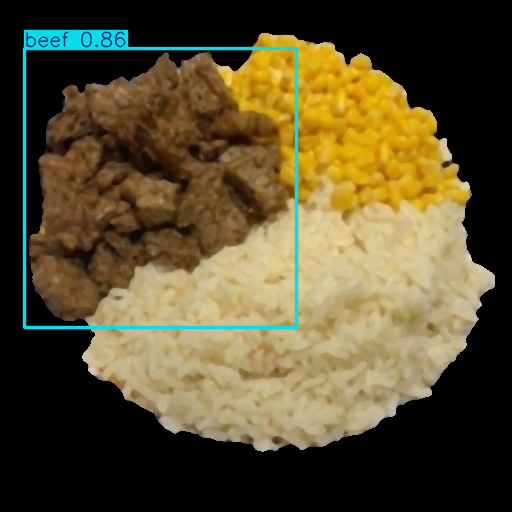

In [16]:
from ultralytics import YOLO
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow

# 1. Carregar o modelo que você acabou de treinar
model = YOLO('/content/runs/detect/train4/weights/best.pt')

# 2. Upload da imagem
print("Selecione uma foto de comida para testar:")
uploaded = files.upload()

for fn in uploaded.keys():
    # 3. Rodar a predição
    results = model.predict(source=fn)

    # 4. Mostrar o resultado visual
    res_plotted = results[0].plot()
    cv2_imshow(res_plotted)